# Chat Stream Stress Analysis

This notebook analyzes results produced by the black-box stress test for `POST /chat/stream`.

The stress runner defaults to the deployed VM endpoint: `https://llm-backend.cloudlab.zhaw.ch/chat/stream`.

Run the stress test from the repository root before executing the notebook:

```bash
uv run python -m tests.stress_tests.chat_stream_load --concurrency-levels 30 60 100 --requests-per-user 1
```

For a quick smoke run:

```bash
uv run python -m tests.stress_tests.chat_stream_load --concurrency-levels 1 2 --requests-per-user 1
```

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULT_CANDIDATES = [
    Path("stress_results/chat_stream_results.csv"),
    Path("../../../stress_results/chat_stream_results.csv"),
]
RESULTS_CSV = next((path for path in RESULT_CANDIDATES if path.exists()), RESULT_CANDIDATES[0])

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        "Missing stress_results/chat_stream_results.csv. "
        "Run the stress test from the repository root first."
    )

def parse_bool(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"true", "1", "yes"}


# The stress runner defaults to https://llm-backend.cloudlab.zhaw.ch.
df = pd.read_csv(RESULTS_CSV, parse_dates=["started_at", "ended_at"])
df["success"] = df["success"].map(parse_bool)
df["done_seen"] = df["done_seen"].map(parse_bool)
df["error_type"] = df["error_type"].fillna("")
df.loc[df["success"] & (df["error_type"] == ""), "error_type"] = "success"
df.loc[~df["success"] & (df["error_type"] == ""), "error_type"] = "unknown"
df["elapsed_since_start_s"] = (
    df["started_at"] - df["started_at"].min()
).dt.total_seconds()

successful_df = df[df["success"]].copy()
failed_df = df[~df["success"]].copy()

plt.style.use("seaborn-v0_8-whitegrid")
df.head()

,run_id,concurrency,user_id,request_id,prompt_chars,started_at,ended_at,status_code,success,done_seen,ttfb_ms,total_latency_ms,chunk_count,bytes_received,error_type,error_message,elapsed_since_start_s
0,20260618T084552Z,30,22,22,97,2026-06-18 08:45:52.703000+00:00,2026-06-18 08:46:01.775000+00:00,200,True,True,355.621,9072.121,123,3044,success,NaN,0.003
1,20260618T084552Z,30,12,12,97,2026-06-18 08:45:52.704000+00:00,2026-06-18 08:46:02.235000+00:00,200,True,True,1028.905,9530.940,130,3212,success,NaN,0.004
2,20260618T084552Z,30,21,21,97,2026-06-18 08:45:52.702000+00:00,2026-06-18 08:46:03.371000+00:00,200,True,True,354.110,10668.798,147,3602,success,NaN,0.002
3,20260618T084552Z,30,8,8,97,2026-06-18 08:45:52.700000+00:00,2026-06-18 08:46:03.568000+00:00,200,True,True,236.602,10867.914,150,3697,success,NaN,0.000
4,20260618T084552Z,30,7,7,97,2026-06-18 08:45:52.705000+00:00,2026-06-18 08:46:03.636000+00:00,200,True,True,1023.378,10931.120,151,3705,success,NaN,0.005


In [5]:
def quantile_or_na(series, q):
    values = series.dropna()
    if values.empty:
        return pd.NA
    return values.quantile(q)


base_summary = (
    df.groupby("concurrency")
    .agg(
        requests=("request_id", "count"),
        successes=("success", "sum"),
        success_rate=("success", "mean"),
        incomplete_streams=("done_seen", lambda s: (~s).sum()),
        mean_request_duration_ms=("total_latency_ms", "mean"),
    )
    .reset_index()
)

if successful_df.empty:
    latency_summary = pd.DataFrame({"concurrency": sorted(df["concurrency"].unique())})
else:
    latency_summary = (
        successful_df.groupby("concurrency")
        .agg(
            mean_latency_ms=("total_latency_ms", "mean"),
            p50_latency_ms=("total_latency_ms", lambda s: quantile_or_na(s, 0.50)),
            p90_latency_ms=("total_latency_ms", lambda s: quantile_or_na(s, 0.90)),
            p95_latency_ms=("total_latency_ms", lambda s: quantile_or_na(s, 0.95)),
            p99_latency_ms=("total_latency_ms", lambda s: quantile_or_na(s, 0.99)),
            mean_ttfb_ms=("ttfb_ms", "mean"),
        )
        .reset_index()
    )

summary = base_summary.merge(latency_summary, on="concurrency", how="left")
summary["failures"] = summary["requests"] - summary["successes"]
summary["failure_rate"] = 1 - summary["success_rate"]
summary.round(3)

,concurrency,requests,successes,success_rate,incomplete_streams,mean_request_duration_ms,mean_latency_ms,p50_latency_ms,p90_latency_ms,p95_latency_ms,p99_latency_ms,mean_ttfb_ms,failures,failure_rate
0,30,30,30,1.0,0,12559.316,12559.316,12849.194,14100.345,14357.979,14732.581,545.862,0,0.0
1,60,60,60,1.0,0,13085.757,13085.757,13156.170,15002.174,15471.008,16009.939,466.661,0,0.0
2,100,100,100,1.0,0,14839.648,14839.648,15035.542,16136.001,16501.837,16881.245,723.387,0,0.0


## Latency distribution

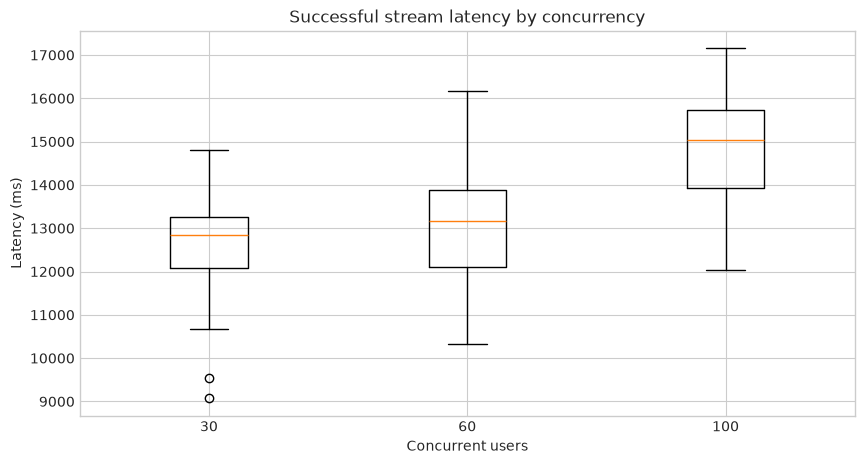

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

if successful_df.empty:
    ax.text(
        0.5,
        0.5,
        "No successful streams recorded.\nCheck the failure charts below and verify the API is running.",
        ha="center",
        va="center",
    )
    ax.set_axis_off()
else:
    latency_data = [
        group["total_latency_ms"].dropna().to_numpy()
        for _, group in successful_df.sort_values("concurrency").groupby("concurrency")
    ]
    labels = [str(level) for level in sorted(successful_df["concurrency"].unique())]
    ax.boxplot(latency_data, tick_labels=labels, showfliers=True)
    ax.set_title("Successful stream latency by concurrency")
    ax.set_xlabel("Concurrent users")
    ax.set_ylabel("Latency (ms)")

plt.show()

## Percentiles and first-token responsiveness

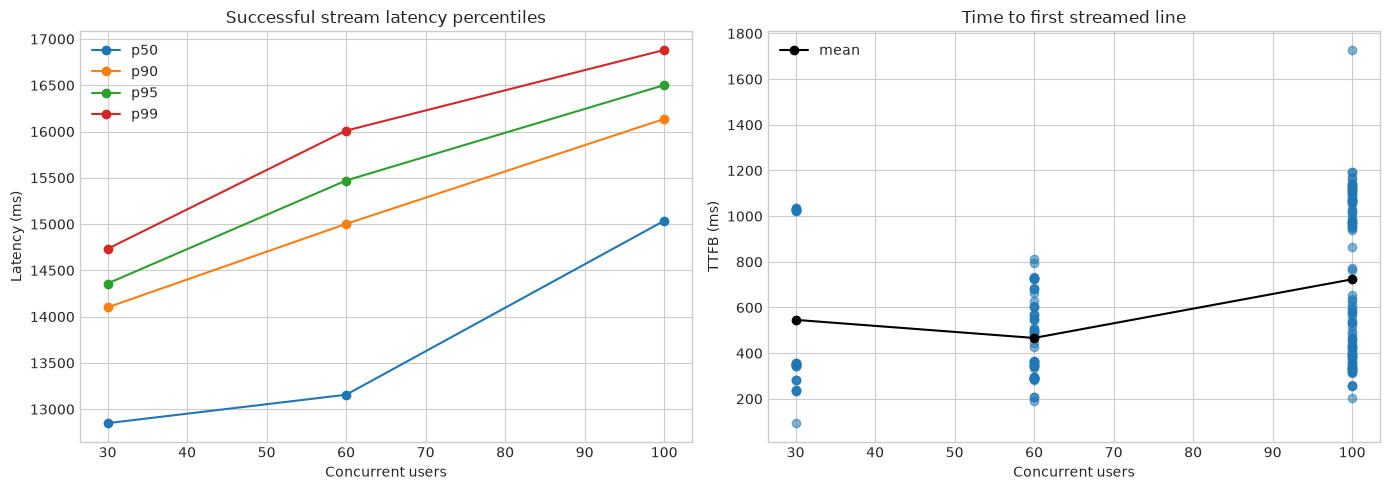

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

latency_columns = [
    ("p50_latency_ms", "p50"),
    ("p90_latency_ms", "p90"),
    ("p95_latency_ms", "p95"),
    ("p99_latency_ms", "p99"),
]
if successful_df.empty:
    axes[0].text(0.5, 0.5, "No successful streams", ha="center", va="center")
    axes[0].set_axis_off()
else:
    for column, label in latency_columns:
        axes[0].plot(summary["concurrency"], summary[column], marker="o", label=label)
    axes[0].set_title("Successful stream latency percentiles")
    axes[0].set_xlabel("Concurrent users")
    axes[0].set_ylabel("Latency (ms)")
    axes[0].legend()

ttfb = successful_df.dropna(subset=["ttfb_ms"])
if ttfb.empty:
    axes[1].text(0.5, 0.5, "No first-byte timings", ha="center", va="center")
    axes[1].set_axis_off()
else:
    axes[1].scatter(ttfb["concurrency"], ttfb["ttfb_ms"], alpha=0.55)
    axes[1].plot(
        summary["concurrency"],
        summary["mean_ttfb_ms"],
        color="black",
        marker="o",
        label="mean",
    )
    axes[1].set_title("Time to first streamed line")
    axes[1].set_xlabel("Concurrent users")
    axes[1].set_ylabel("TTFB (ms)")
    axes[1].legend()

plt.tight_layout()
plt.show()

## Failure and incomplete-stream signals

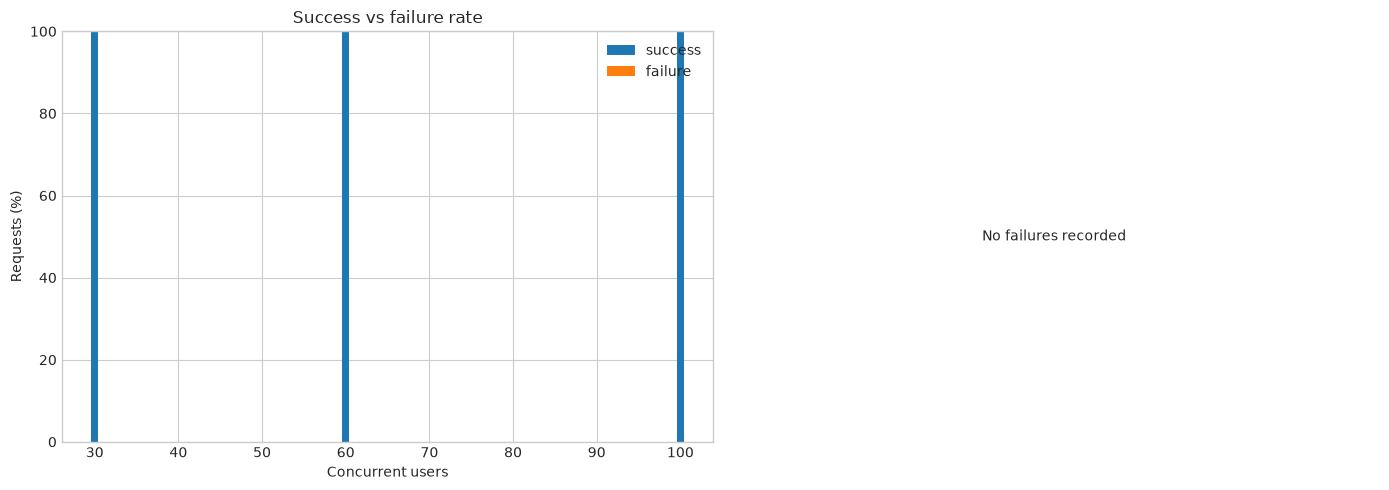

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary["concurrency"], summary["success_rate"] * 100, label="success")
axes[0].bar(
    summary["concurrency"],
    summary["failure_rate"] * 100,
    bottom=summary["success_rate"] * 100,
    label="failure",
)
axes[0].set_title("Success vs failure rate")
axes[0].set_xlabel("Concurrent users")
axes[0].set_ylabel("Requests (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()

error_counts = (
    df.loc[~df["success"]]
    .groupby(["concurrency", "error_type"])
    .size()
    .unstack(fill_value=0)
)
if error_counts.empty:
    axes[1].text(0.5, 0.5, "No failures recorded", ha="center", va="center")
    axes[1].set_axis_off()
else:
    error_counts.plot(kind="bar", stacked=True, ax=axes[1])
    axes[1].set_title("Failure categories")
    axes[1].set_xlabel("Concurrent users")
    axes[1].set_ylabel("Failed requests")

plt.tight_layout()
plt.show()

## Throughput over time

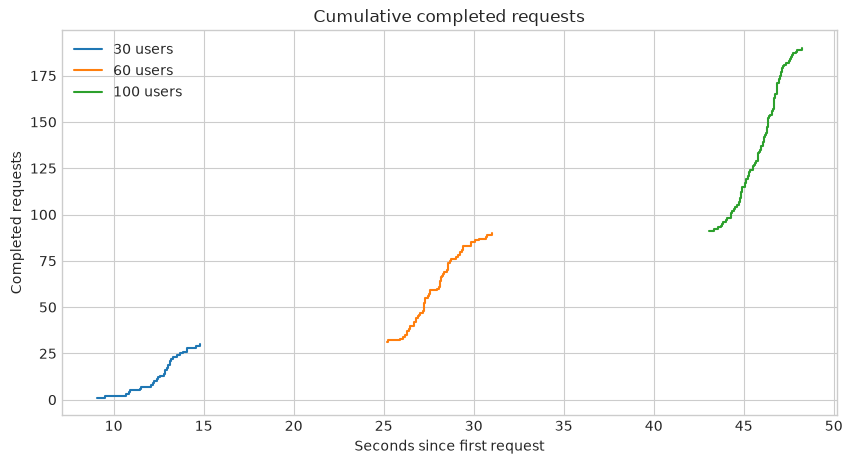

In [9]:
completed = df.sort_values("ended_at").copy()
completed["completed_since_start_s"] = (
    completed["ended_at"] - completed["started_at"].min()
).dt.total_seconds()
completed["completed_requests"] = range(1, len(completed) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
for concurrency, group in completed.groupby("concurrency"):
    ax.step(
        group["completed_since_start_s"],
        group["completed_requests"],
        where="post",
        label=f"{concurrency} users",
    )
ax.set_title("Cumulative completed requests")
ax.set_xlabel("Seconds since first request")
ax.set_ylabel("Completed requests")
ax.legend()
plt.show()